10000
132
             object    mean       std  min  max
0  RoomType.KITCHEN  2.9372  0.242651    2    3
      expected_room t1_err t2_err t3_err
                       sum    sum    sum
0  RoomType.KITCHEN      0     50    107
  t125_score      
             count
0          2   157
1          3  2343


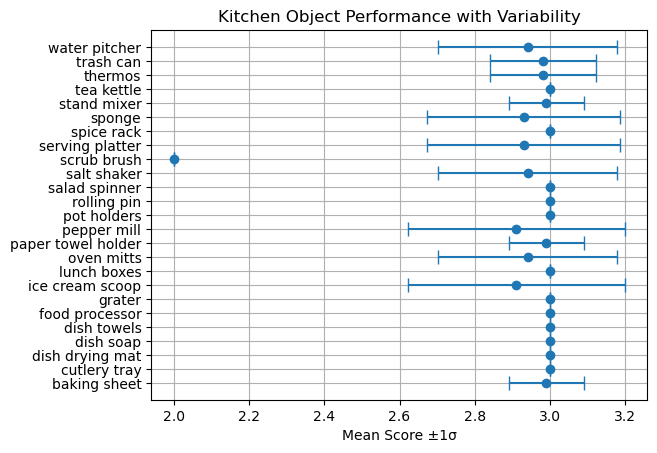

              object   mean       std  min  max
0  RoomType.BATHROOM  2.838  0.369609    1    3
       expected_room t1_err t2_err t3_err
                        sum    sum    sum
0  RoomType.BATHROOM      0     19    386
  t125_score      
             count
0          1     1
1          2   403
2          3  2096


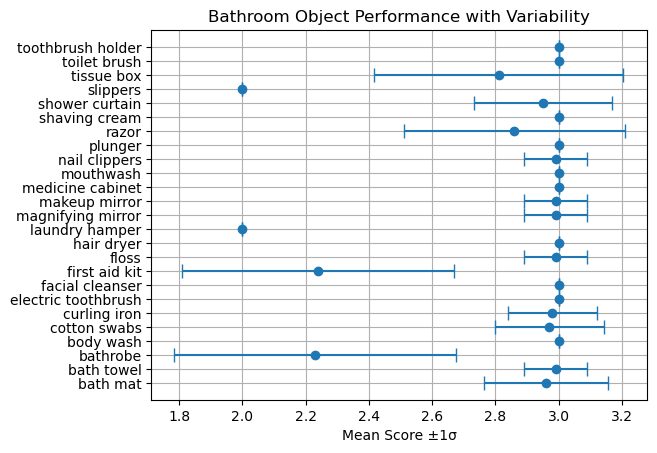

                 object    mean       std  min  max
0  RoomType.LIVING_ROOM  2.8864  0.339324    0    3
          expected_room t1_err t2_err t3_err
                           sum    sum    sum
0  RoomType.LIVING_ROOM      6     77    201
  t125_score      
             count
0          0     6
1          2   266
2          3  2228


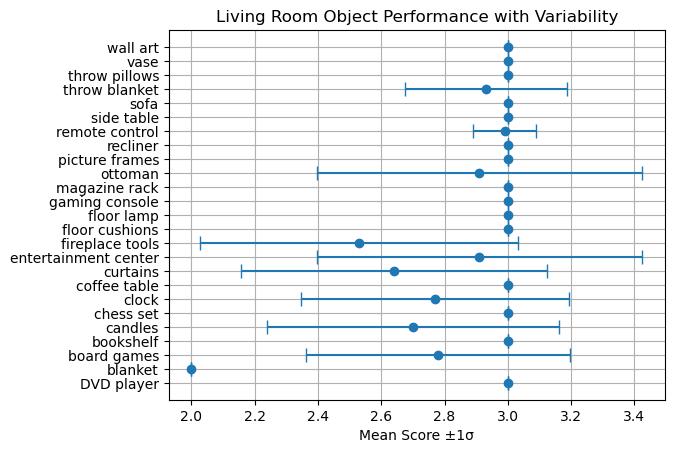

             object    mean       std  min  max
0  RoomType.BEDROOM  2.6328  0.736329    0    3
      expected_room t1_err t2_err t3_err
                       sum    sum    sum
0  RoomType.BEDROOM    126    180    612
  t125_score      
             count
0          0   126
1          1     9
2          2   522
3          3  1843


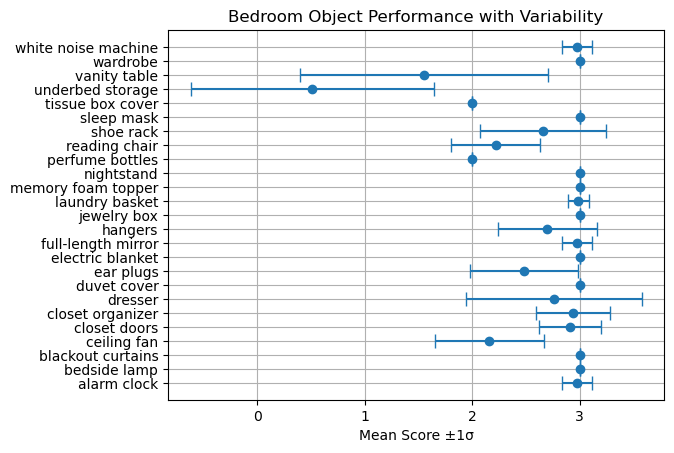

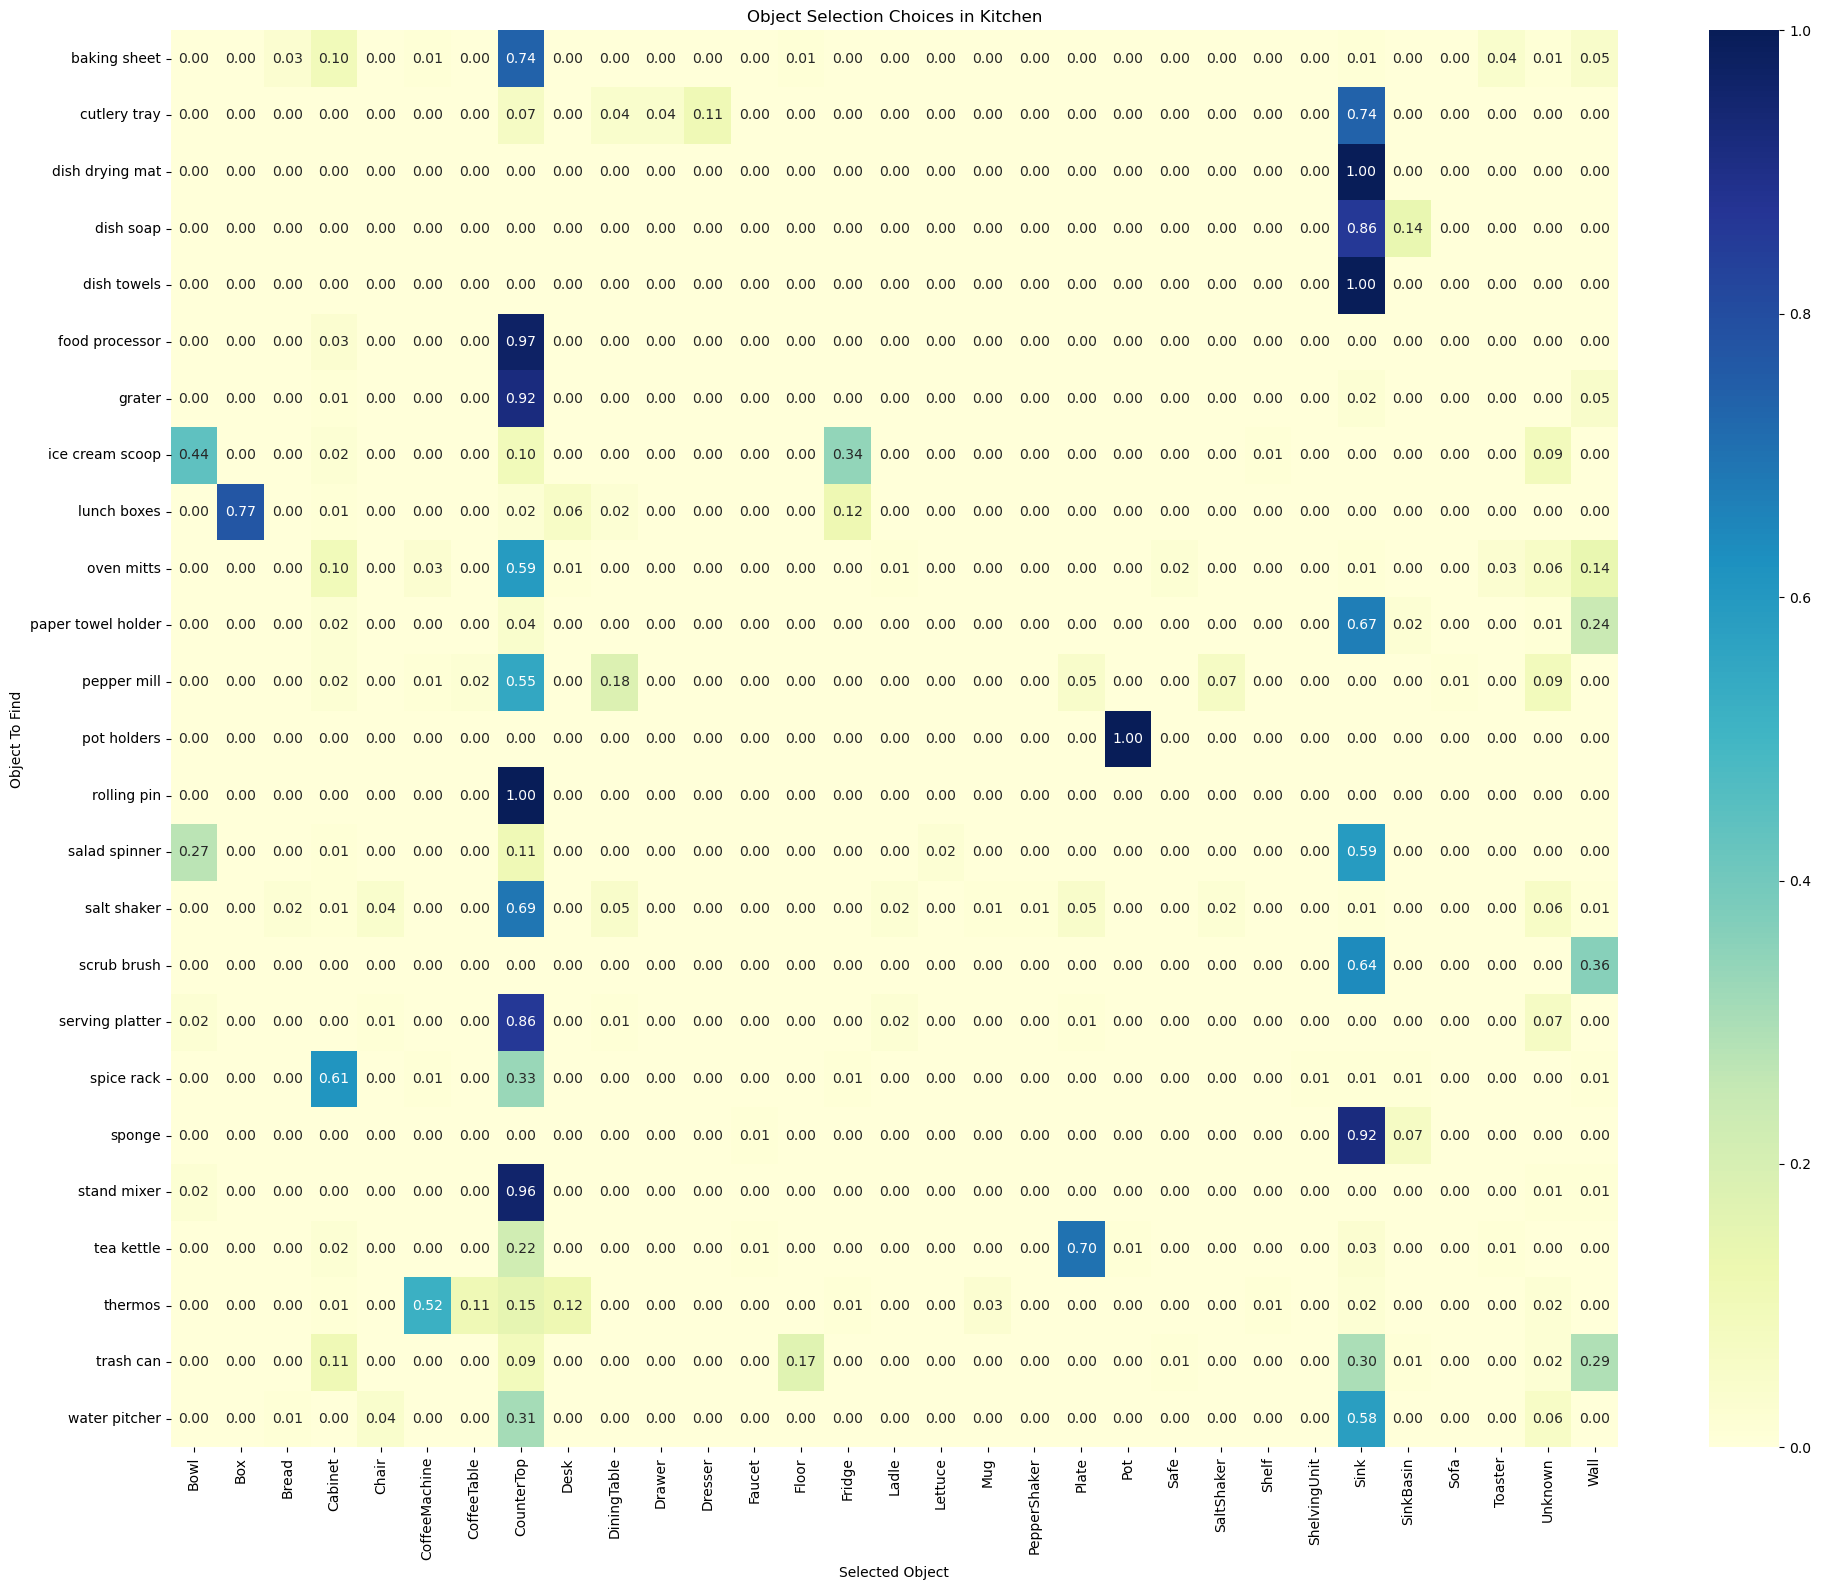

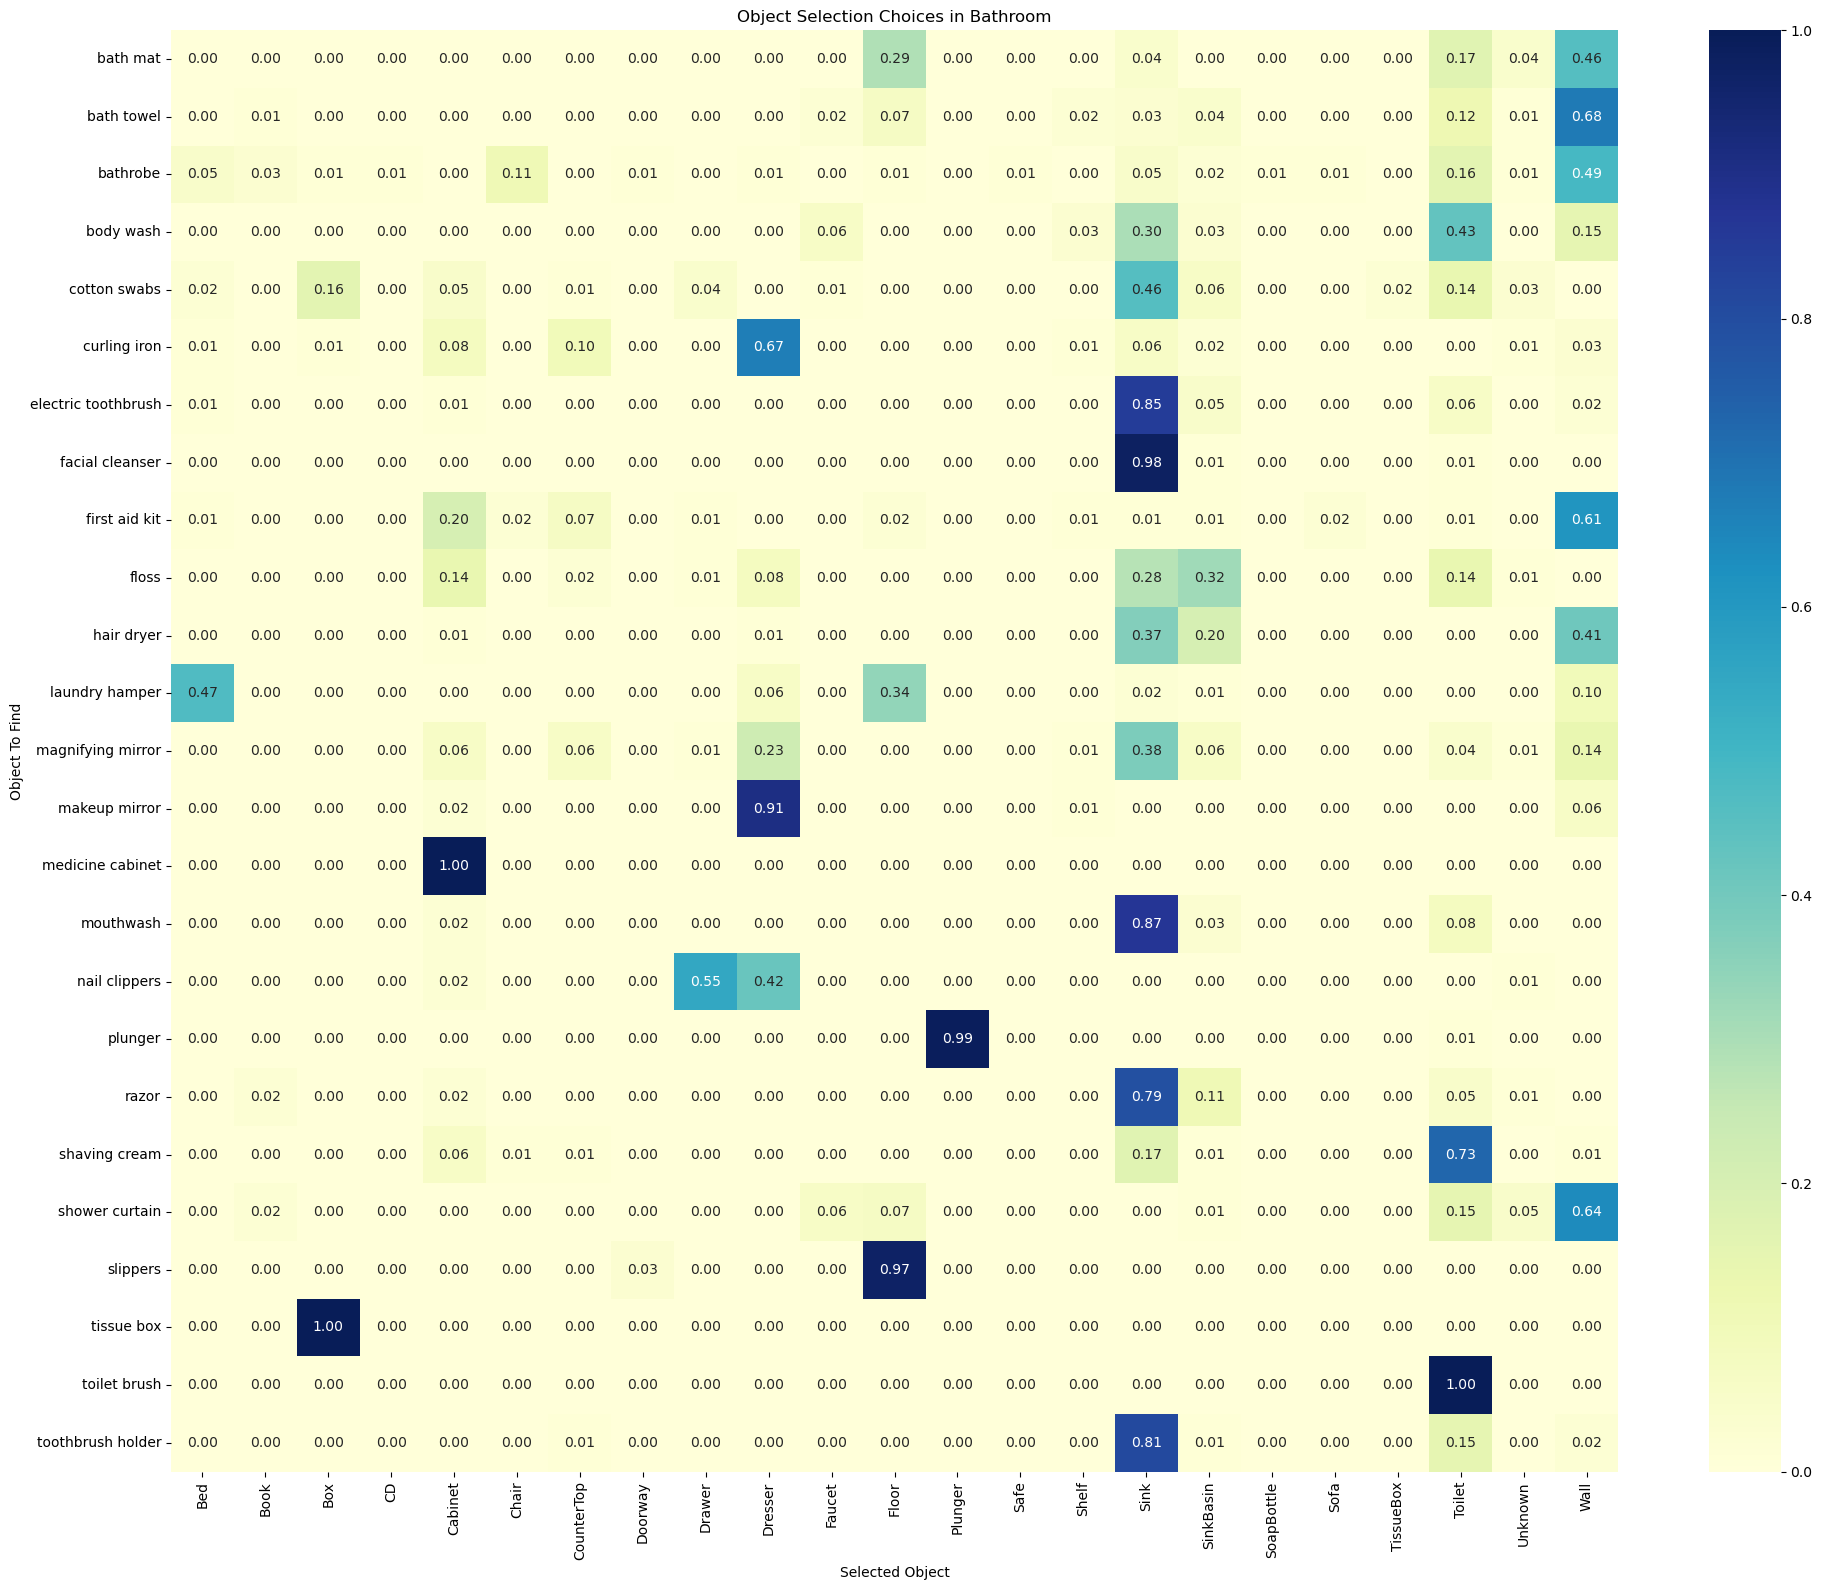

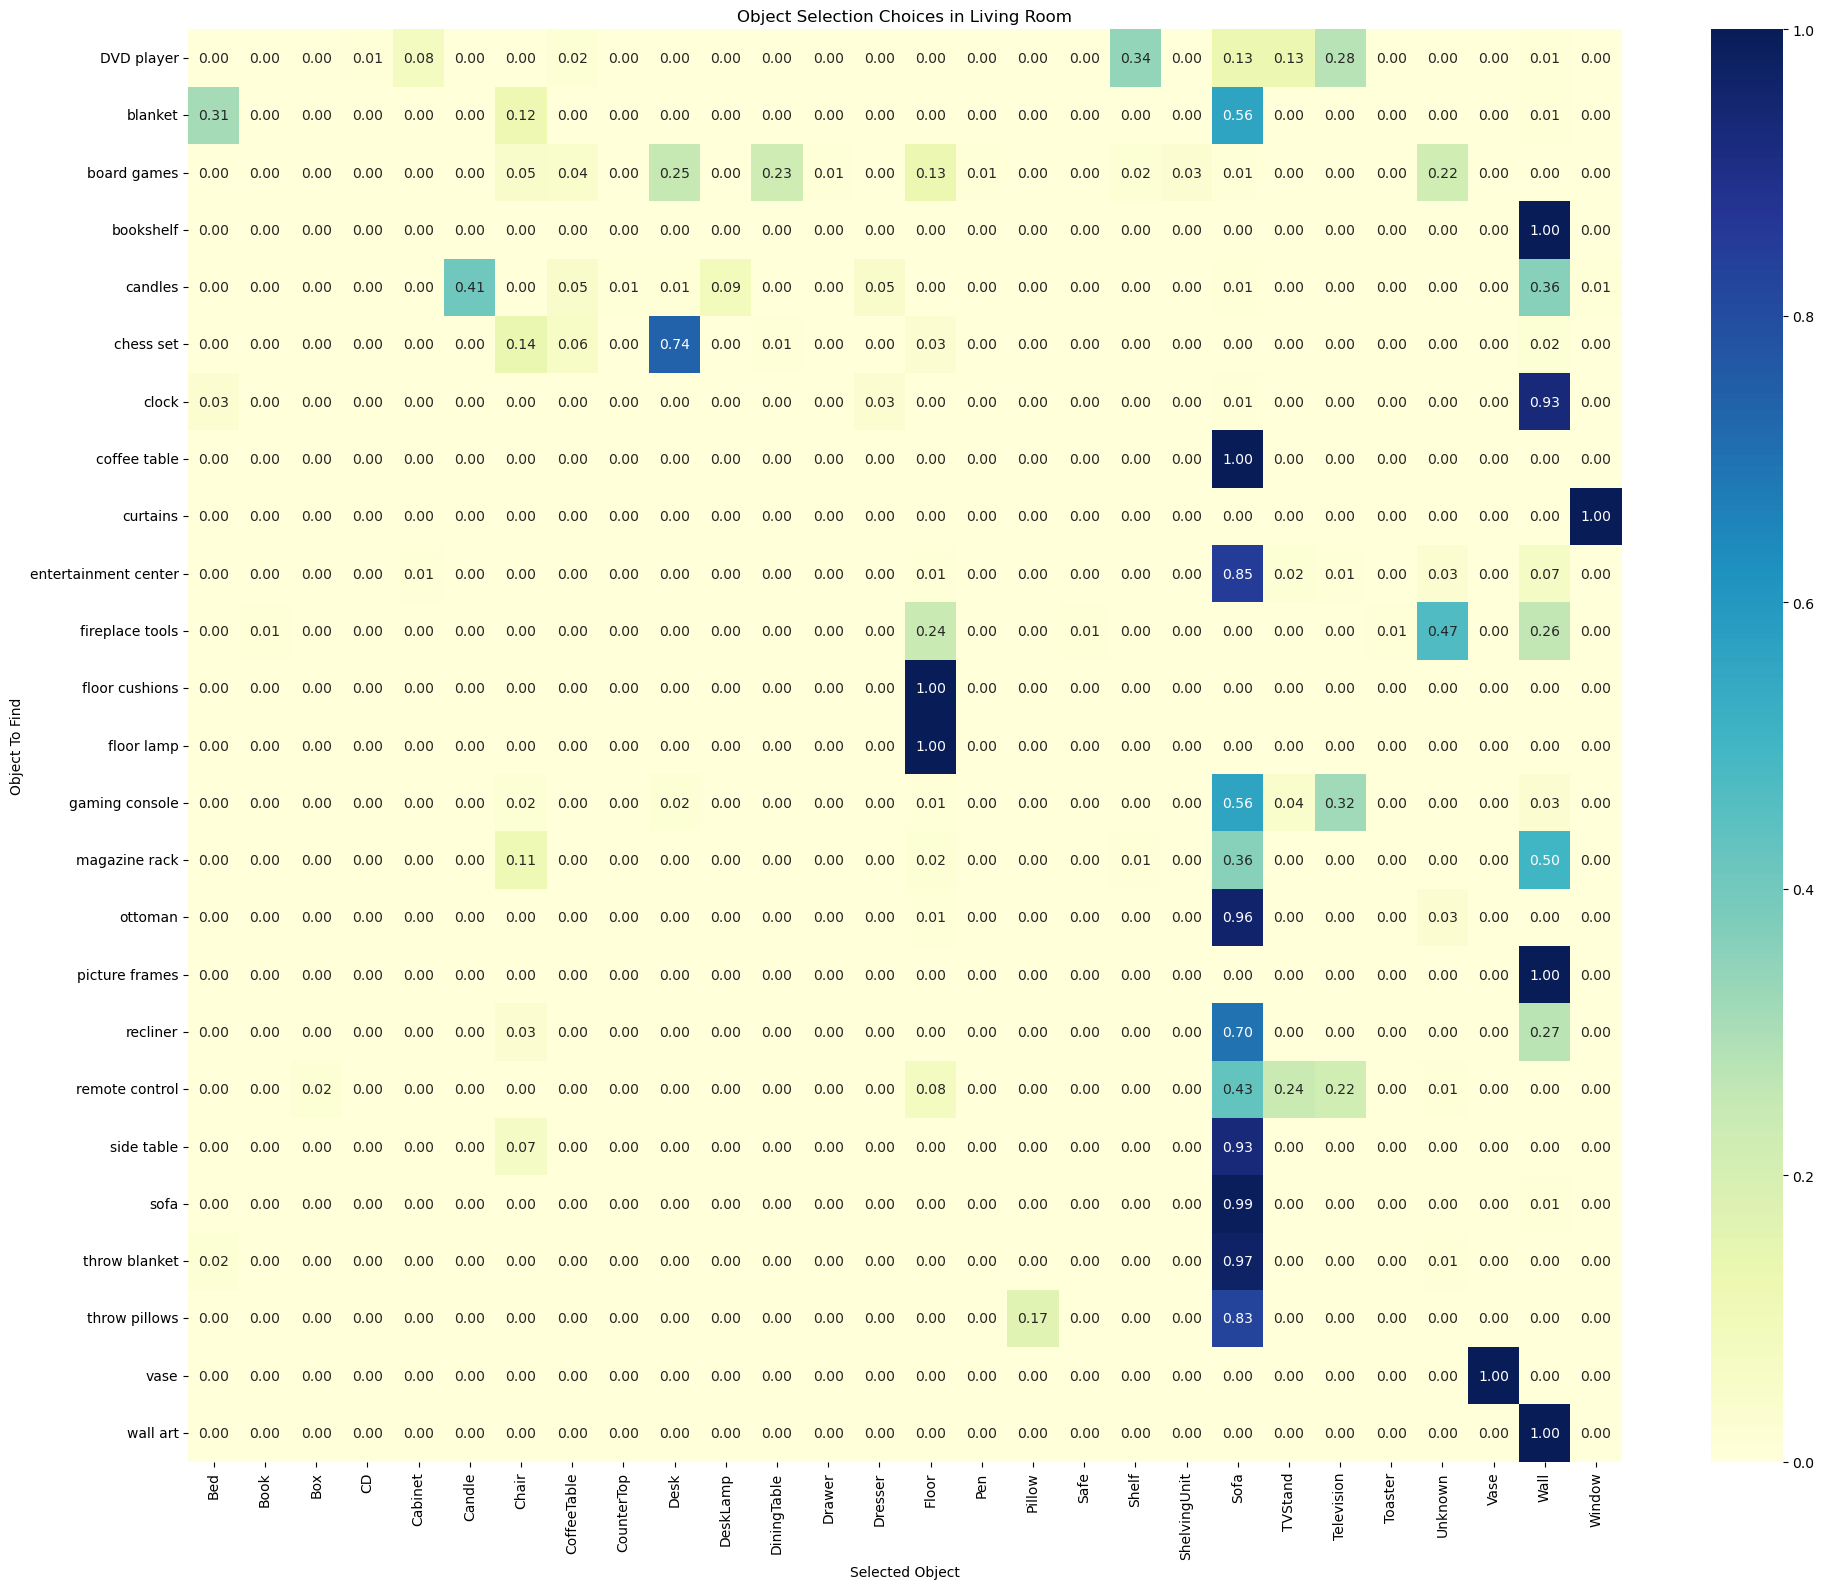

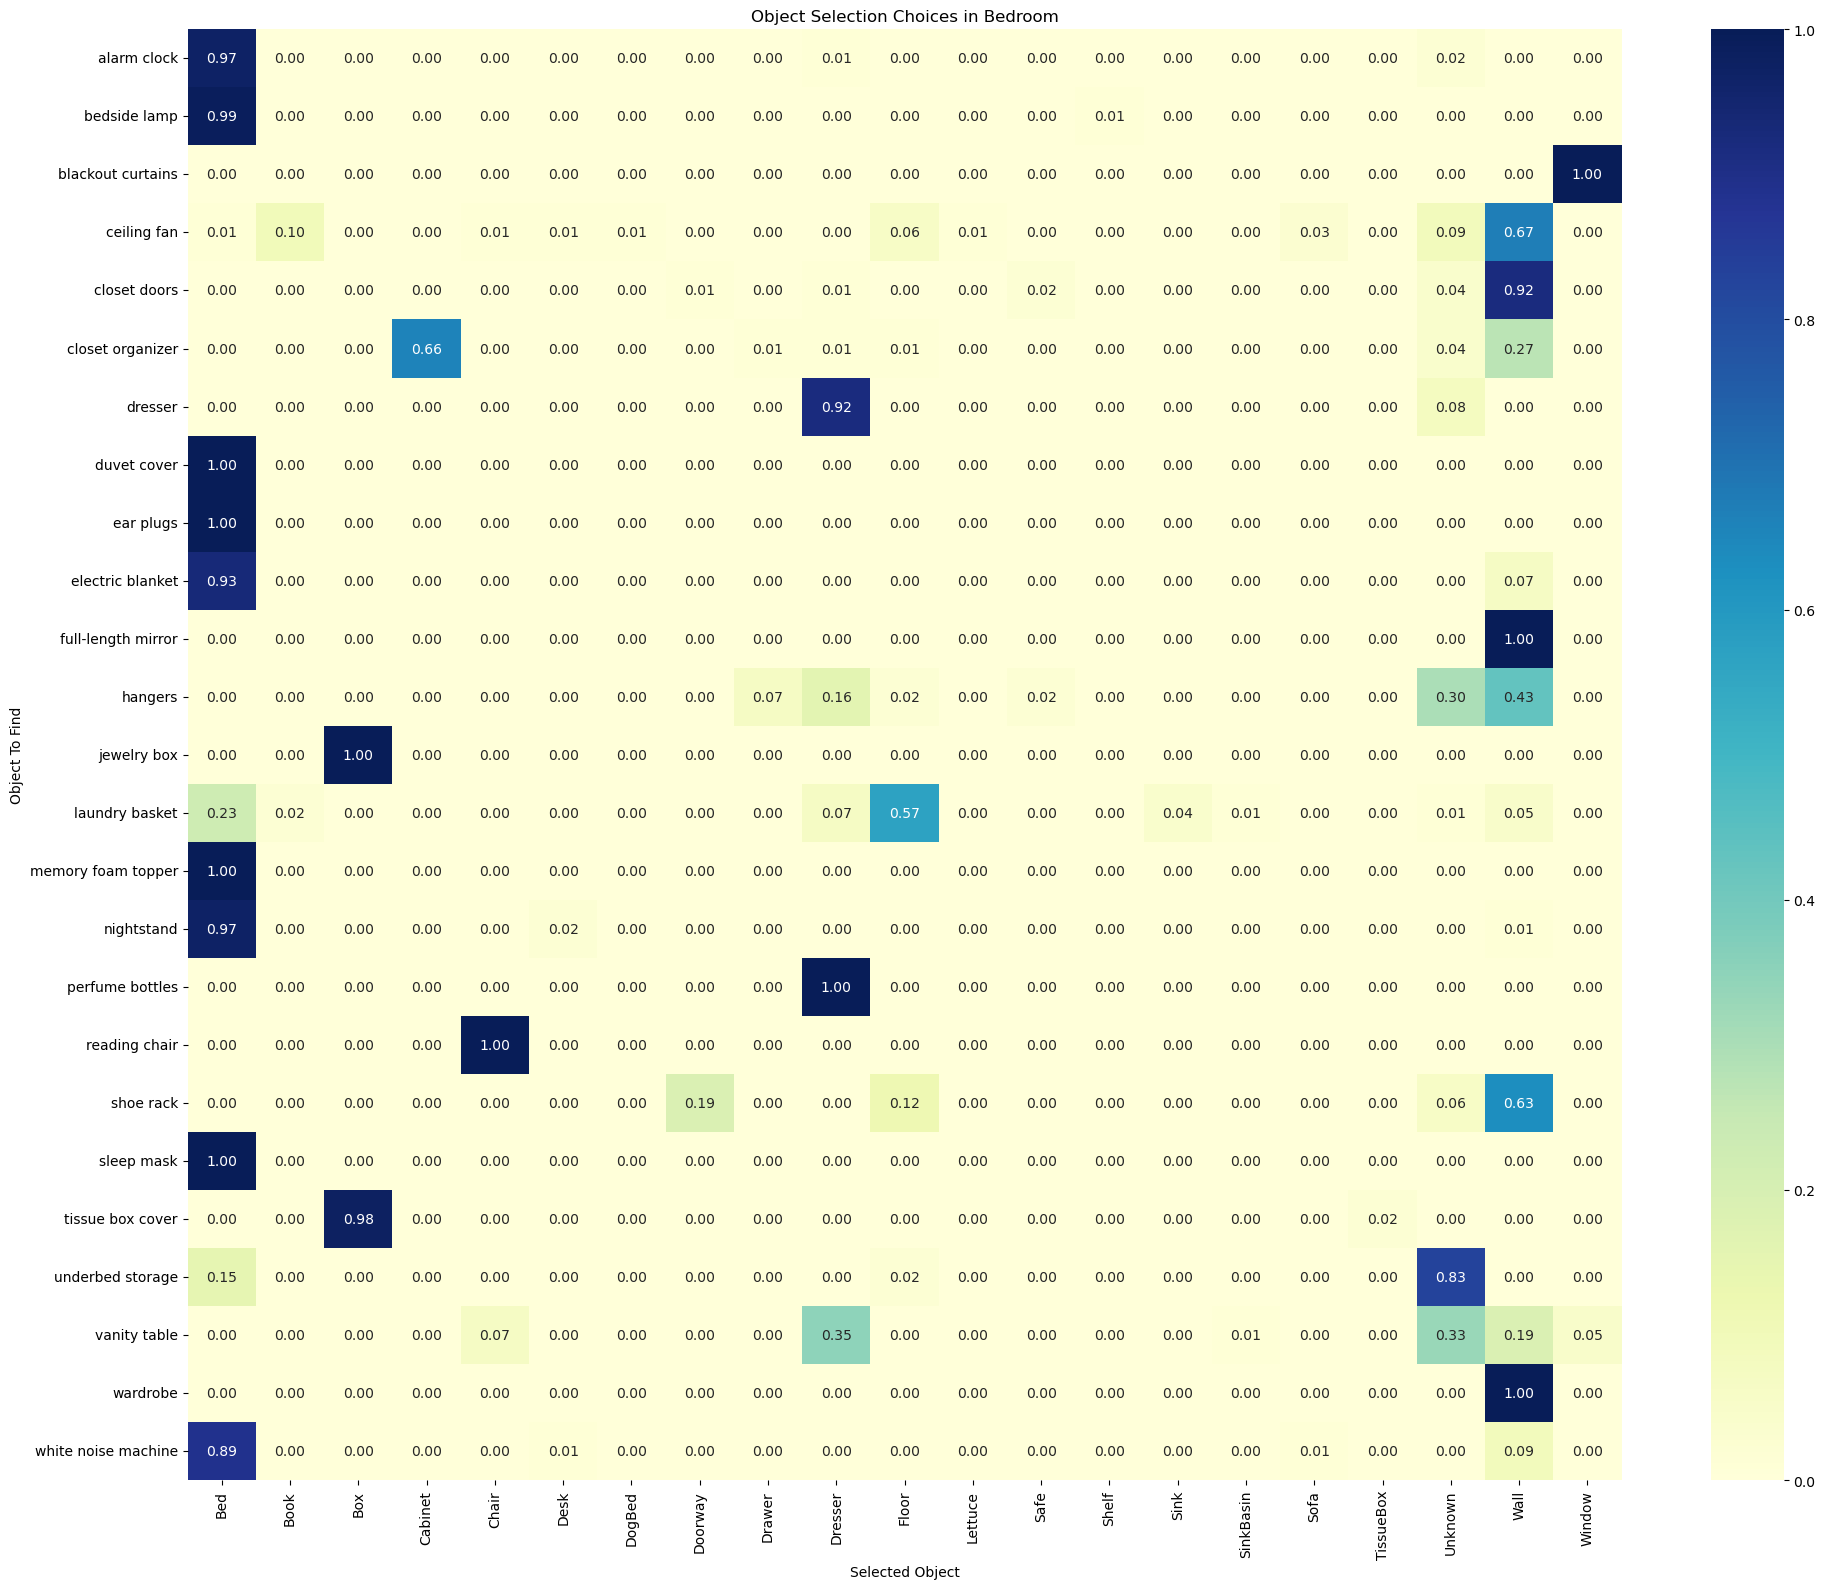

/tmp/ipykernel_355256/3848101200.py:235: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  success_rate = df.groupby('expected_room').apply(


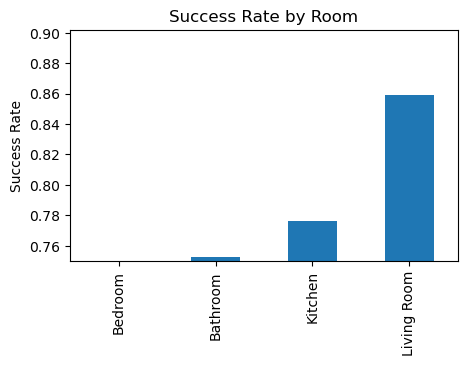

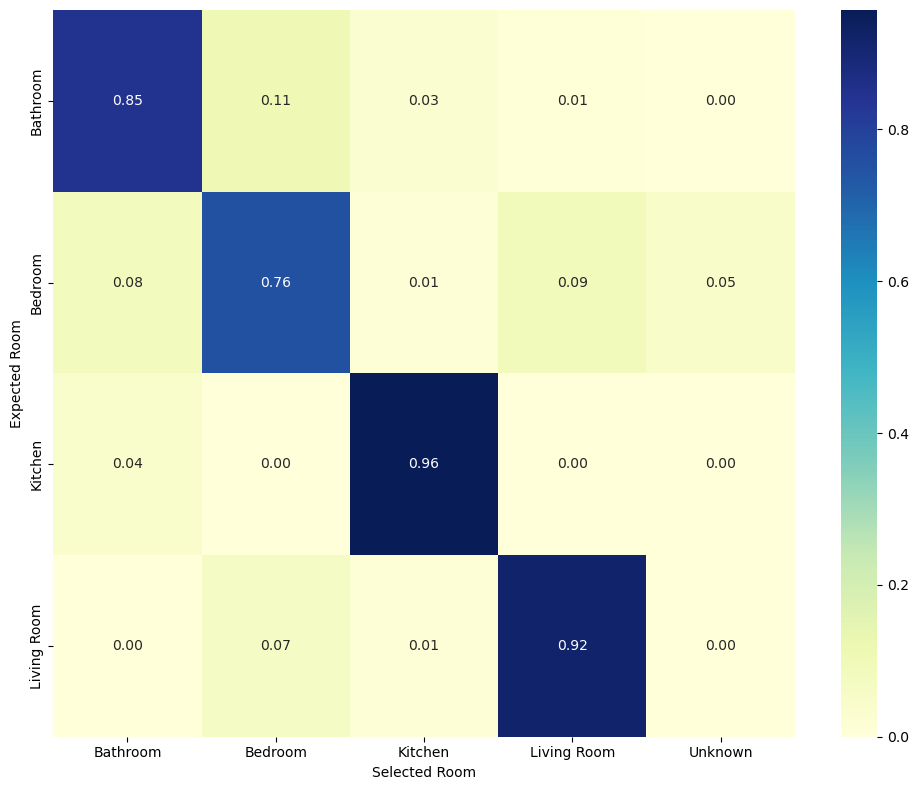

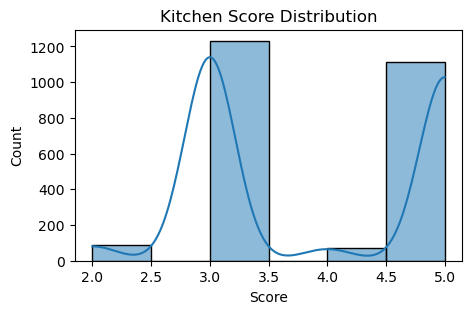

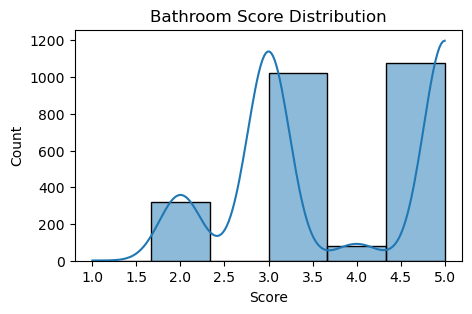

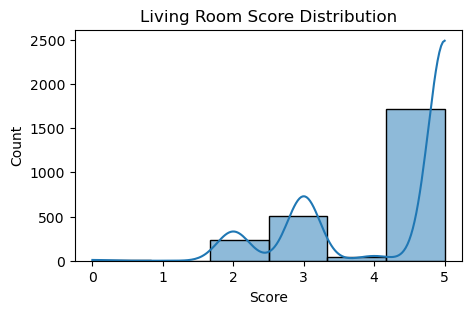

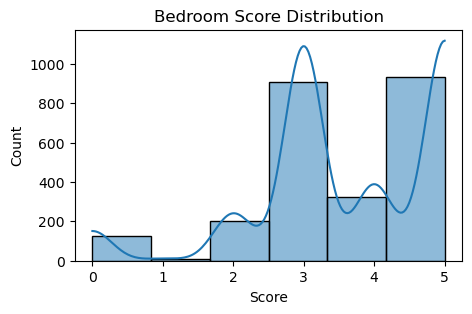

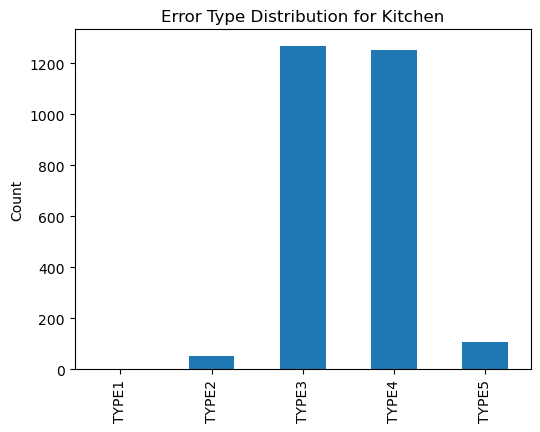

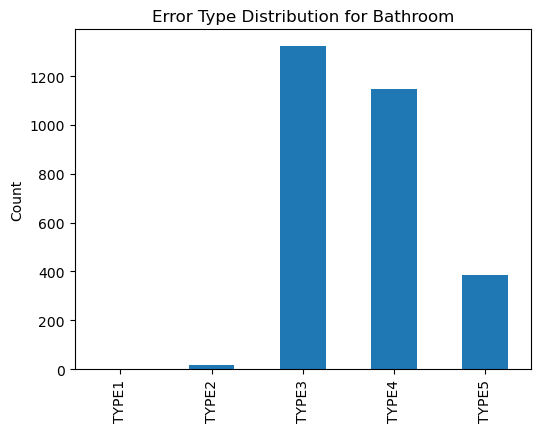

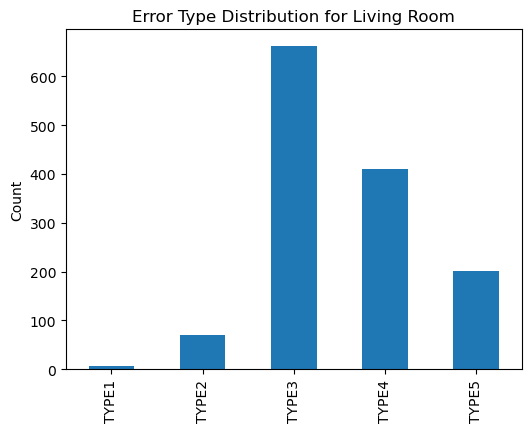

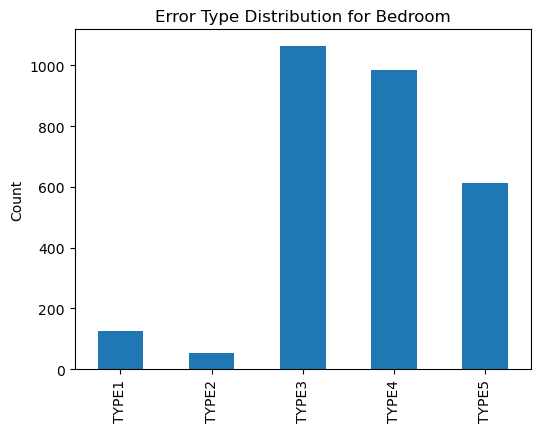

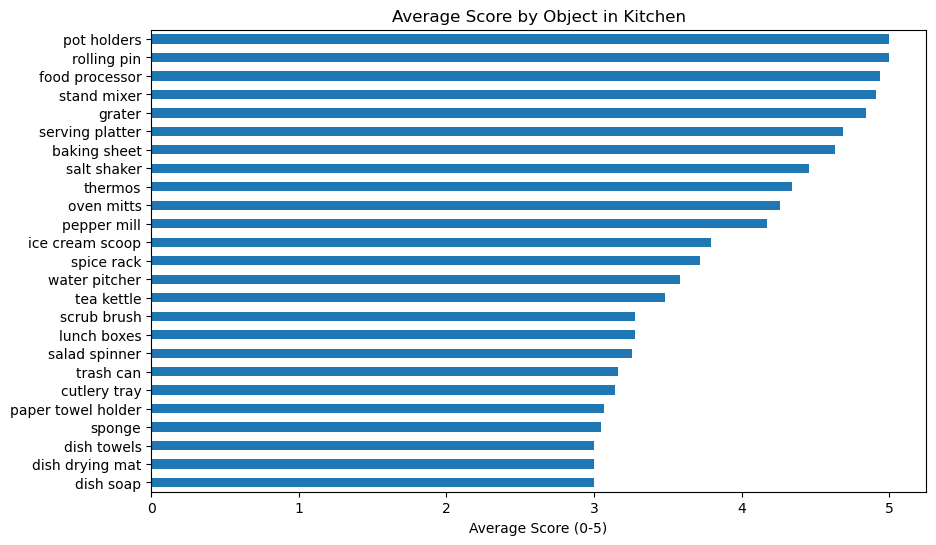

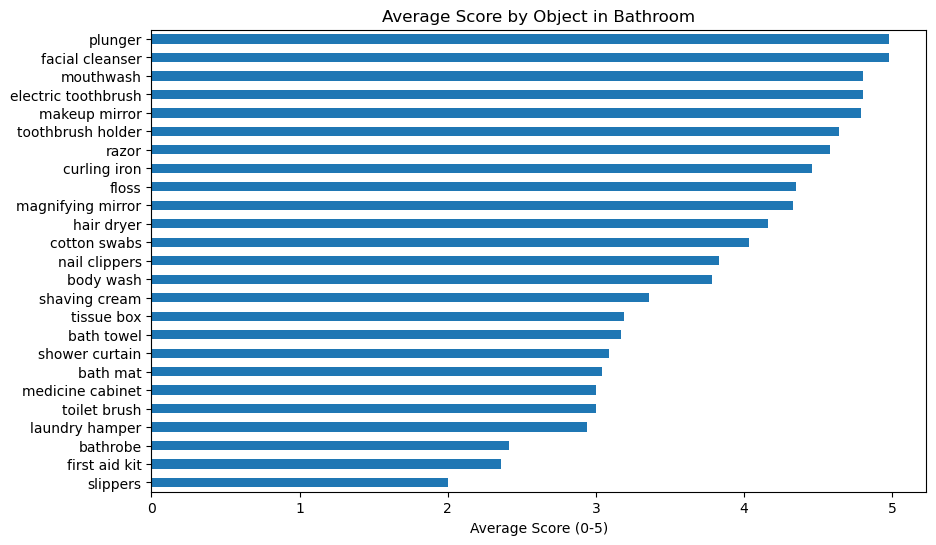

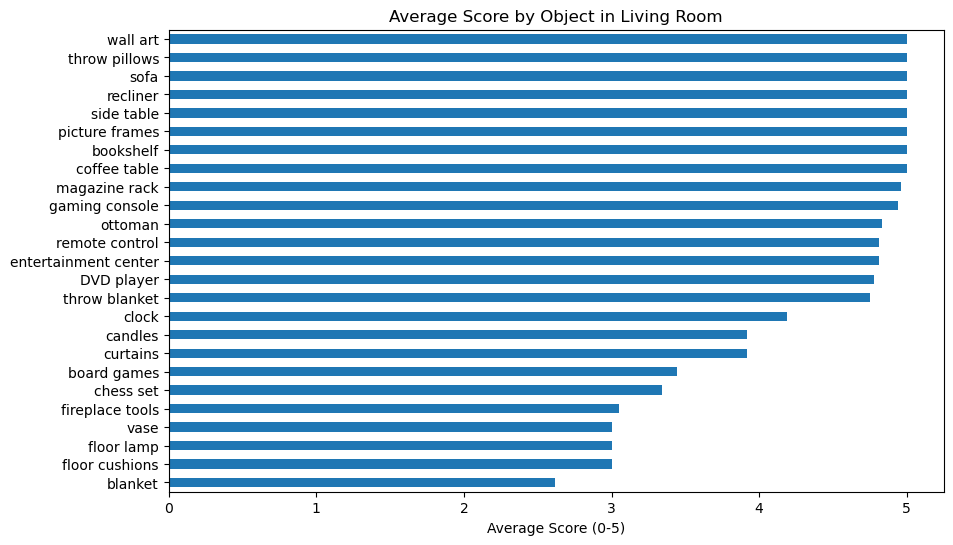

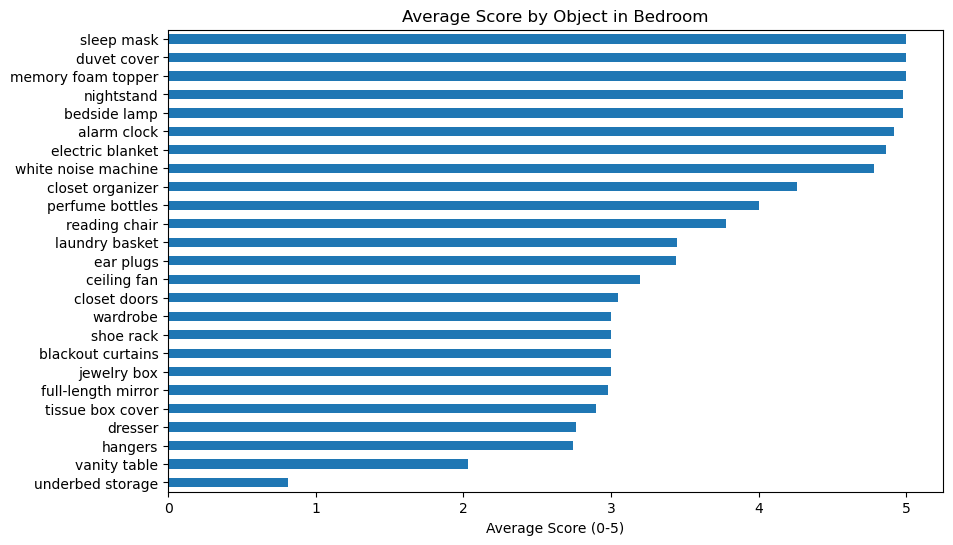

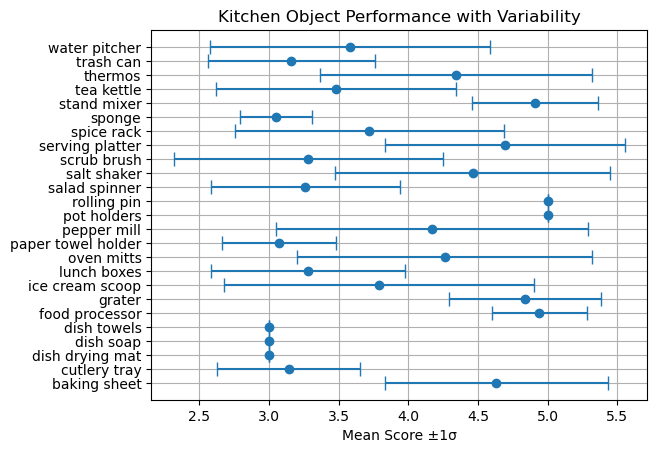

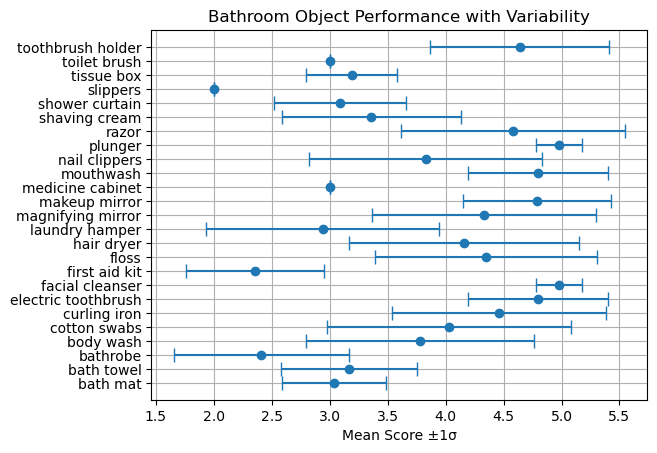

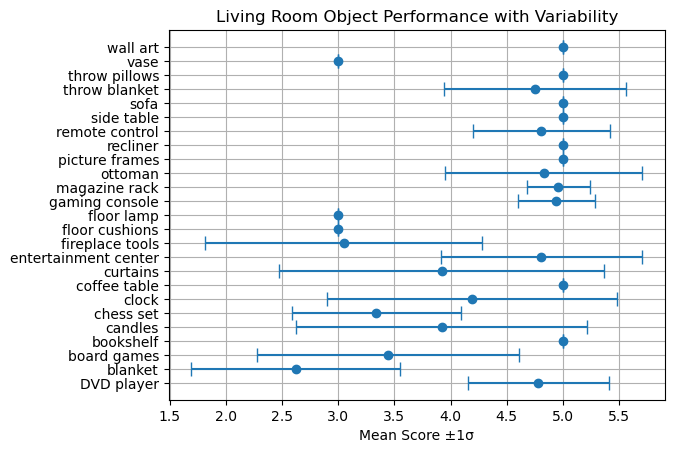

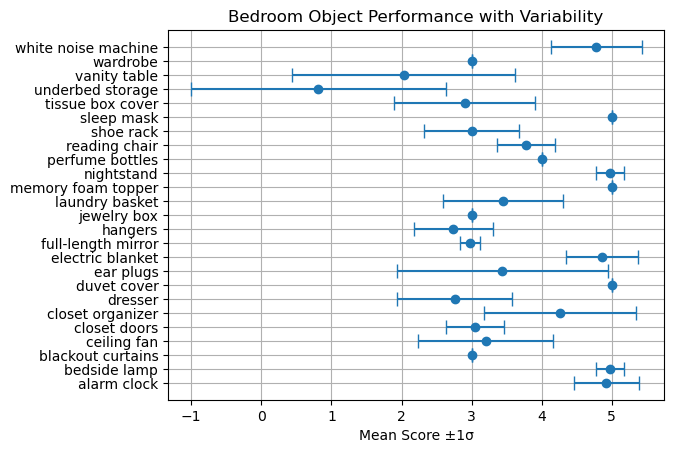

In [81]:
import glob
import pickle
from scene_description import SceneDescription
import shutil, os
import pandas as pd
import matplotlib.pyplot as plt
from llm_room_classifier import LLMType
import seaborn as sns

class GoalSelectionAnalysis:
    def __init__(self, llm_type):
        self.LLM_TYPE = llm_type.name
        kitchen_results = self.process_scene_files("Kitchen")
        bathroom_results = self.process_scene_files("Bathroom")
        living_room_results = self.process_scene_files("Living Room")
        bedroom_results = self.process_scene_files("Bedroom")

        self.all_results = kitchen_results
        self.all_results.extend(bathroom_results)
        self.all_results.extend(living_room_results)
        self.all_results.extend(bedroom_results)
        print(len(self.all_results))

        noroom = 0
        for item in self.all_results:
            if(item["selected_room"] is None):
                #print(item)
                noroom += 1
        print(noroom)
        
    def process_scene_files(self, room):
        pkl_store = "experiment_data/test_" + self.LLM_TYPE + "/" + room + "/*.pkl"
    
        pkl_files = glob.glob(pkl_store) # files showing gemma scenes
        #scene_files2 = glob.glob(pkl_store2)
    
        results = []
        for test_f in pkl_files:
            f = open(test_f,'rb')
            test_res = pickle.load(f)
    
            #print(f)
            #print(test_res)
            results.extend(test_res)
    
        return results
    
    # Function to convert result dictionaries to DataFrame
    def convert_results_to_df(self, results_list):
        """Convert a list of result dictionaries to a pandas DataFrame."""
        room_type_fx_results = []
        for item in results_list:
            #print(item["expected_room"].value)
            #if (item["object_to_find"] in [#"dish soap"
                #"tea kettle", "food processor", "stand mixer", "rolling pin", "baking sheet",
                #"pot holders", "oven mitts", "dish towels", "spice rack", "salt shaker",
                #"pepper mill", "cutlery tray", "serving platter", "salad spinner", "ice cream scoop",
                #"grater", "thermos", "lunch boxes", "water pitcher", "paper towel holder",
                #"trash can", "dish soap", "sponge", "scrub brush", "dish drying mat"
            #]):
            #    room_type_fx_results.append(item)
                #pass
            room_type_fx_results.append(item)
        return pd.DataFrame(room_type_fx_results)
        #return pd.DataFrame(results_list)
    
    def show_error_bars(self, room):
        room_results = self.process_scene_files(room)
        # Process data
        df = self.convert_results_to_df(room_results)
        ##print(df)
        ##room_success = df.groupby(['expected_room', 'selected_room']).size().unstack().fillna(0)
        #room_success = df.groupby(['object_to_find'])
        #print(room_success.size().fillna(0))
        #print(df)
        obj_stats = df.groupby('object_to_find').agg({
            'score_for_this_run': ['mean', 'std']
        }).reset_index()
        
        obj_stats.columns = ['object', 'mean_score', 'std_score']
        
        #print(obj_stats)
        
        plt.errorbar(
            x=obj_stats['mean_score'],
            y=obj_stats['object'],
            xerr=obj_stats['std_score'],
            fmt='o',
            capsize=5
        )
        plt.title(room + ' Object Performance with Variability')
        plt.xlabel('Mean Score ±1σ')
        plt.grid(True)
        plt.show()

    def show_mean_bars(self, room):
        room_results = self.process_scene_files(room)
        df = self.convert_results_to_df(room_results)
        
        # Average score by object
        #ax2 = plt.subplot2grid((3, 3), (0, 1), colspan=2)
        fig, ax2 = plt.subplots(figsize=(10, 6))  # ax2 is your axis object
        avg_scores = df.groupby('object_to_find')['score_for_this_run'].mean().sort_values()
        avg_scores.plot(kind='barh', ax=ax2)
        ax2.set_title('Average Score by Object in ' + room)
        ax2.set_xlabel('Average Score (0-5)')
        ax2.set_ylabel("")
        plt.show()
    
    def show_error_types(self, room):
        room_results = self.process_scene_files(room)
        df = self.convert_results_to_df(room_results)

        # TYPE1: No room was selected, from the available ones (usually due to LLM not giving an interpretable answer)
        # TYPE2: No object was selected from the available ones (usually due to LLM not giving an interpretable answer)
        # TYPE3: Object was selected, but it is in a different room than was expected (usually due to room mis-classification)
        # TYPE4: Path was generated, but it led to a different room than initially expected (usually due to path planning leading to a vicinity of the target, but in a different room)
        # TYPE5: LLM made its decisions and navigated to where it navigated, but it ended up not where we (humans) expected.
        
        # Calculate error types
        df['TYPE1'] = (df['selected_room'].isna()).astype(int)
        df['TYPE2'] = (df['selected_room'].notna() & df['selected_object_name'].isna()).astype(int)
        df['TYPE3'] = ((df['selected_object_name'].notna()) & (df['selected_room'] != df['room_where_selected_object_is'])).astype(int)
        df['TYPE4'] = ((df['path_end_point_room'].notna()) & (df['selected_room'] != df['path_end_point_room'])).astype(int)
        df['TYPE5'] = (df['expected_room'] != df['selected_room']).astype(int)
        
        fig = plt.figure(figsize=(20, 15))
        
        # 1. Overall error distribution
        ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=1)
        error_counts = df[['TYPE1', 'TYPE2', 'TYPE3', 'TYPE4', 'TYPE5']].sum()
        error_counts.plot(kind='bar', ax=ax1)
        ax1.set_title('Error Type Distribution for ' + room)
        ax1.set_ylabel('Count')
        plt.show()

    def show_score_distribution(self, room):
        # 5. Score distribution
        room_results = self.process_scene_files(room)
        df = self.convert_results_to_df(room_results)

        fig, ax5 = plt.subplots(figsize=(5, 3))  # ax2 is your axis object
        #ax5 = plt.subplot2grid((3, 3), (2, 1), colspan=1)
        sns.histplot(df['score_for_this_run'], kde=True, bins=6, ax=ax5)
        ax5.set_title(room + ' Score Distribution')
        ax5.set_xlabel('Score')
        plt.show()

    def show_room_selection_accuracy(self):
        """Create a heatmap showing room selection accuracy."""
        df = self.convert_results_to_df(self.all_results)

        # Custom formatter (e.g., capitalize, remove underscores)
        def format_room(enum_item):
            if enum_item is None:
                return "Unknown"
            else:
                return enum_item.name.replace('_', ' ').title()  # "BATHROOM" → "Bathroom"

        #df['expected_room'] = df['expected_room'].apply(lambda x: x.name if pd.notna(x) else 'Unknown')
        df['expected_room'] = df['expected_room'].apply(format_room)
        #df['selected_room'] = df['selected_room'].apply(lambda x: x.name if pd.notna(x) else 'Unknown')
        df['selected_room'] = df['selected_room'].apply(format_room)
        
        # Create contingency table of expected vs selected rooms
        room_contingency = pd.crosstab(
            df['expected_room'], 
            df['selected_room'], 
            normalize='index'
        )
        
        # Strip enum class names
        #room_contingency.index = room_contingency.index.map(lambda x: x.name)
        #room_contingency.columns = room_contingency.columns.map(lambda x: x.name)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(room_contingency, annot=True, cmap='YlGnBu', fmt='.2f')
        #plt.title('Room Selection Accuracy')
        plt.xlabel('Selected Room')
        plt.ylabel('Expected Room')
        plt.tight_layout()
        
        plt.show()

    def show_object_selection_choices(self, room):
        """Create a heatmap showing room selection accuracy."""
        room_results = self.process_scene_files(room)
        df = self.convert_results_to_df(room_results)

        # Custom formatter (e.g., capitalize, remove underscores)
        def format_room(object_name):
            if object_name is None:
                return "Unknown"
            else:
                return object_name

        #df['expected_room'] = df['expected_room'].apply(lambda x: x.name if pd.notna(x) else 'Unknown')
        df['object_to_find'] = df['object_to_find'].apply(format_room)
        #df['selected_room'] = df['selected_room'].apply(lambda x: x.name if pd.notna(x) else 'Unknown')
        df['selected_object_name'] = df['selected_object_name'].apply(format_room)
        
        # Create contingency table of expected vs selected rooms
        room_contingency = pd.crosstab(
            df['object_to_find'], 
            df['selected_object_name'], 
            normalize='index'
        )
        
        # Strip enum class names
        #room_contingency.index = room_contingency.index.map(lambda x: x.name)
        #room_contingency.columns = room_contingency.columns.map(lambda x: x.name)
        
        plt.figure(figsize=(20, 16))
        sns.heatmap(room_contingency, annot=True, cmap='YlGnBu', fmt='.2f')
        plt.title('Object Selection Choices in ' + room)
        plt.ylabel('Object To Find')
        plt.xlabel('Selected Object')
        plt.tight_layout()
        
        plt.show()

    def success_by_room(self):
        # 6. Success rate by room
        df = self.convert_results_to_df(self.all_results)
        fig, ax6 = plt.subplots(figsize=(5, 3))  # ax2 is your axis object

        def format_room(enum_item):
            if enum_item is None:
                return "Unknown"
            else:
                return enum_item.name.replace('_', ' ').title()  # "BATHROOM" → "Bathroom"
        
        df['expected_room'] = df['expected_room'].apply(format_room)
        
        success_rate = df.groupby('expected_room').apply(
            lambda x: (x['score_for_this_run'] / 5.0).mean()
        ).sort_values()
        success_rate.plot(kind='bar', ax=ax6)
        ax6.set_title('Success Rate by Room')
        ax6.set_ylabel('Success Rate')
        ax6.set_xlabel('')
        ax6.set_ylim(bottom=0.75)  # Bars will be clipped below this value

        plt.show()

    def show_results_ignoring_misclassification_and_path(self, room):
        room_results = self.process_scene_files(room)
        df = self.convert_results_to_df(room_results)

        # Now re-score the results. Instead of taking the score_for_this_run field,
        # we will give it 1 point if room is selected (any room), 1 more point if 
        # object is selected (any object) and 1 more point if the selected room
        # is the same as the expected room
        df['t125_score'] = (df['selected_room'].notna()).astype(int) + (df['selected_object_name'].notna()).astype(int) + (df['expected_room'] == df['selected_room']).astype(int)
        df['t125_score_1'] = (df['selected_room'].notna()).astype(int)
        df['t125_score_2'] = (df['selected_object_name'].notna()).astype(int)
        df['t125_score_3'] = (df['expected_room'] == df['selected_room']).astype(int)

        # Count error types
        df['t1_err'] = (df['selected_room'].isna()).astype(int)
        df['t2_err'] = (df['selected_object_name'].isna()).astype(int)
        df['t3_err'] = (df['expected_room'] != df['selected_room']).astype(int)

        score_per_obj_stats = df.groupby('object_to_find').agg({
            't125_score': ['mean', 'std']
        }).reset_index()

        score_per_obj_stats.columns = ['object', 'mean_score', 'std_score']
        # Pretty display with 2 decimal places
        score_per_obj_stats.style.format({
            'mean_score': '{:.2f}',
            'std_score': '{:.2f}'
        })
        #print(score_per_obj_stats)
        
        score_per_room_stats = df.groupby('expected_room').agg({
            't125_score': ['mean', 'std', 'min', 'max']
        }).reset_index()

        score_per_room_stats.columns = ['object', 'mean', 'std', 'min', 'max']
        # Pretty display with 2 decimal places
        score_per_room_stats.style.format({
            'mean': '{:.2f}',
            'var': '{:.2f}'
        })
        
        print(score_per_room_stats)

        # Show error types
        err_types_per_room_stats = df.groupby('expected_room').agg({
            't1_err': ['sum'],
            't2_err': ['sum'],
            't3_err': ['sum']
        }).reset_index()

        print(err_types_per_room_stats)
        
        score_type_stats = df.groupby('t125_score').agg({
            't125_score': ['count']
        }).reset_index()
        print(score_type_stats)
        #print(df)
                
        #print(score_per_obj_stats)
        
        plt.errorbar(
            x=score_per_obj_stats['mean_score'],
            y=score_per_obj_stats['object'],
            xerr=score_per_obj_stats['std_score'],
            fmt='o',
            capsize=5
        )
        plt.title(room + ' Object Performance with Variability')
        plt.xlabel('Mean Score ±1σ')
        plt.grid(True)
        plt.show()

gsa = GoalSelectionAnalysis(LLMType.MISTRAL_6b)
#gsa = GoalSelectionAnalysis(LLMType.MISTRAL_4b)
#gsa = GoalSelectionAnalysis(LLMType.LLAMA)
#gsa = GoalSelectionAnalysis(LLMType.GEMMA)

gsa.show_results_ignoring_misclassification_and_path("Kitchen")
gsa.show_results_ignoring_misclassification_and_path("Bathroom")
gsa.show_results_ignoring_misclassification_and_path("Living Room")
gsa.show_results_ignoring_misclassification_and_path("Bedroom")

gsa.show_object_selection_choices("Kitchen")
gsa.show_object_selection_choices("Bathroom")
gsa.show_object_selection_choices("Living Room")
gsa.show_object_selection_choices("Bedroom")

gsa.success_by_room()

gsa.show_room_selection_accuracy()

gsa.show_score_distribution("Kitchen")
gsa.show_score_distribution("Bathroom")
gsa.show_score_distribution("Living Room")
gsa.show_score_distribution("Bedroom")

gsa.show_error_types("Kitchen")
gsa.show_error_types("Bathroom")
gsa.show_error_types("Living Room")
gsa.show_error_types("Bedroom")

gsa.show_mean_bars("Kitchen")
gsa.show_mean_bars("Bathroom")
gsa.show_mean_bars("Living Room")
gsa.show_mean_bars("Bedroom")

gsa.show_error_bars("Kitchen")
gsa.show_error_bars("Bathroom")
gsa.show_error_bars("Living Room")
gsa.show_error_bars("Bedroom")

#room_success = room_success.div(room_success.sum(axis=1), axis=0) * 100  # Convert to percentages

In [17]:
from scipy import stats
import seaborn as sns

data=[1,1,1,1,5]
data = [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3]
stats.describe(data)
#sns.violinplot(data=data)
#sns.boxplot(data=data)

DescribeResult(nobs=100, minmax=(np.int64(2), np.int64(3)), mean=np.float64(2.69), variance=np.float64(0.21606060606060598), skewness=np.float64(-0.8216336251223799), kurtosis=np.float64(-1.3249181860682546))

In [70]:
gsa = GoalSelectionAnalysis(LLMType.MISTRAL_6b)
room_results = gsa.process_scene_files("Bedroom")
df = gsa.convert_results_to_df(room_results)

df['t125_score'] = (df['selected_room'].notna()).astype(int) + (df['selected_object_name'].notna()).astype(int) + (df['expected_room'] == df['selected_room']).astype(int)
df['t125_score_1'] = (df['selected_room'].notna()).astype(int)
df['t125_score_2'] = (df['selected_object_name'].notna()).astype(int)
df['t125_score_3'] = (df['expected_room'] == df['selected_room']).astype(int)
df['t125_score_t'] = df['t125_score_1'] + df['t125_score_2'] + df['t125_score_3']


# Count error types
df['t1_err'] = (df['selected_room'].isna()).astype(int)
df['t2_err'] = (df['selected_object_name'].isna()).astype(int)
df['t3_err'] = (df['expected_room'] != df['selected_room']).astype(int)

#print(df)

# Show error types
err_types_per_room_stats = df.groupby('expected_room').agg({
    't1_err': ['sum'],
    't2_err': ['sum'],
    't3_err': ['sum']
}).reset_index()

print(err_types_per_room_stats)

score_per_obj_stats = df.groupby('expected_room').agg({
    't125_score': ['mean', 'std']
}).reset_index()
print(score_per_obj_stats)

score_per_obj_stats_t = df.groupby('expected_room').agg({
    't125_score_t': ['mean', 'std']
}).reset_index()
print(score_per_obj_stats_t)

score_per_obj_stats_t = df.groupby('expected_room').agg({
    't125_score_t': ['count']
}).reset_index()
print(score_per_obj_stats_t)

filtered_all_err = df[(df['t1_err'] != 1) & (df['t2_err'] == 1) & (df['t3_err'] == 1)]
print(filtered_all_err)

10000
132
      expected_room t1_err t2_err t3_err
                       sum    sum    sum
0  RoomType.BEDROOM    126    180    612
      expected_room t125_score          
                          mean       std
0  RoomType.BEDROOM     2.6328  0.736329
      expected_room t125_score_t          
                            mean       std
0  RoomType.BEDROOM       2.6328  0.736329
      expected_room t125_score_t
                           count
0  RoomType.BEDROOM         2500
     object_to_find     expected_room         selected_room  \
715       shoe rack  RoomType.BEDROOM  RoomType.LIVING_ROOM   
788       shoe rack  RoomType.BEDROOM  RoomType.LIVING_ROOM   
790       shoe rack  RoomType.BEDROOM  RoomType.LIVING_ROOM   
1205    ceiling fan  RoomType.BEDROOM  RoomType.LIVING_ROOM   
1226    ceiling fan  RoomType.BEDROOM  RoomType.LIVING_ROOM   
1230    ceiling fan  RoomType.BEDROOM  RoomType.LIVING_ROOM   
1267    ceiling fan  RoomType.BEDROOM  RoomType.LIVING_ROOM   
1270    ceil